# Handwritten Digit Recognizer

Euclidean Distance to USPS Average Templates


In [12]:
import os
from typing import Tuple

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------
IMAGE_SIZE: int = 16  # USPS images are 16 x 16 pixels
NUM_LABELS: int = 10  # digits 0 - 9

TARGET_SIZE: int = 16  # Final image edge length (pixels)
PADDING_FRACTION: float = 0.05  # Extra margin added around the bounding-box crop
# (expressed as a fraction of the bounding-box size)
SUPPORTED_EXTENSIONS: Tuple[str, ...] = (".png", ".jpg", ".jpeg", ".bmp")

# Minimum component area as a fraction of the total image area.
# Components smaller than this threshold are classified as noise and discarded.
# 0.05% keeps even faint strokes of disconnected digits (e.g. "4", "5") while
# reliably removing JPEG/photo sensor noise dots.
NOISE_AREA_THRESHOLD: float = 0.0005  # 0.05 % of image area

#### 1. Load USPS dataset from Hugging Face


In [13]:
from datasets import Dataset, load_dataset, concatenate_datasets

print("[Templates] Loading USPS dataset from Hugging Face...")
dataset = load_dataset("flwrlabs/usps")
all_data: Dataset = concatenate_datasets([dataset[split] for split in dataset.keys()])
print(f"  Total samples: {len(all_data):,}")

[Templates] Loading USPS dataset from Hugging Face...
  Total samples: 9,298


#### 2. Build Images by Label

Iterates over a dataset split and groups images as nested lists by label.


  Processing 9,298 samples...
    [9,298/9,298] images processed


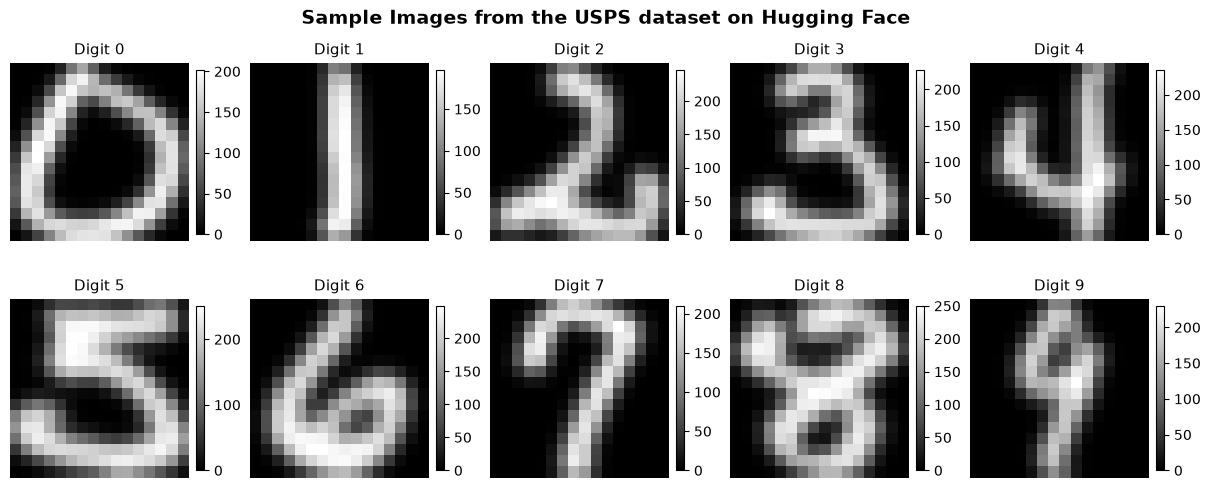

In [14]:
from typing import Any, Dict, List

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Pre-populate dictionary keys for safety and predictable order
images_by_label: Dict[int, List[List[List[int]]]] = {
    label: [] for label in range(NUM_LABELS)
}

total = len(all_data)
print(f"  Processing {total:,} samples...")

print_samples: Dict[int, Image.Image | None] = {
    label: None for label in range(NUM_LABELS)
}

for idx, sample in enumerate(all_data):
    sample: Any = sample
    label = int(sample["label"])
    pil_img: Image.Image = sample["image"]  # Python Imaging Library

    # Validate label range
    if label < 0 or label >= NUM_LABELS:
        raise ValueError(f"Encountered unexpected label value: {label}")

    if print_samples[label] == None:
        print_samples[label] = pil_img

    # Convert image to grayscale ('L' mode) to discard color channels safely. Luminosity levels.
    pil_gray = pil_img.convert("L")

    # Resize defensively in case dataset contains variant dimensions
    if pil_gray.size != (IMAGE_SIZE, IMAGE_SIZE):
        pil_gray = pil_gray.resize(
            (IMAGE_SIZE, IMAGE_SIZE), resample=Image.Resampling.LANCZOS
        )

    arr = np.array(pil_gray, dtype=np.uint8)

    # Validate array dimensions
    if arr.shape != (IMAGE_SIZE, IMAGE_SIZE):
        raise ValueError(
            f"Expected array shape ({IMAGE_SIZE}, {IMAGE_SIZE}), got {arr.shape}"
        )

    # Converted PIL -> NumPy -> 2D nested Python list for JSON compatibility
    images_by_label[label].append(arr.tolist())

    # Progress reporting every 1,000 images
    if (idx + 1) % 1000 == 0 or (idx + 1) == total:
        print(f"    [{idx + 1:,}/{total:,}] images processed", end="\r")

print()  # Finalize progress line

# Display sample training images for each digit
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(12, 5), constrained_layout=True)
fig.suptitle(
    "Sample Images from the USPS dataset on Hugging Face",
    fontsize=14,
    fontweight="bold",
)

for label, ax in zip(range(NUM_LABELS), axes.flat):
    if print_samples[label] is not None:
        im = ax.imshow(print_samples[label], cmap="gray", interpolation="nearest")
        ax.set_title(f"Digit {label}", fontsize=11)
        # Attach color bar for precise scaling reference
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.axis("off")

plt.show()

#### 3. Compute Pixel-wise Averages

Computes the pixel-wise mean image for each digit label.


  A dictionary of NumPy arrays of shape (16, 16) containing pixel averages is computed.


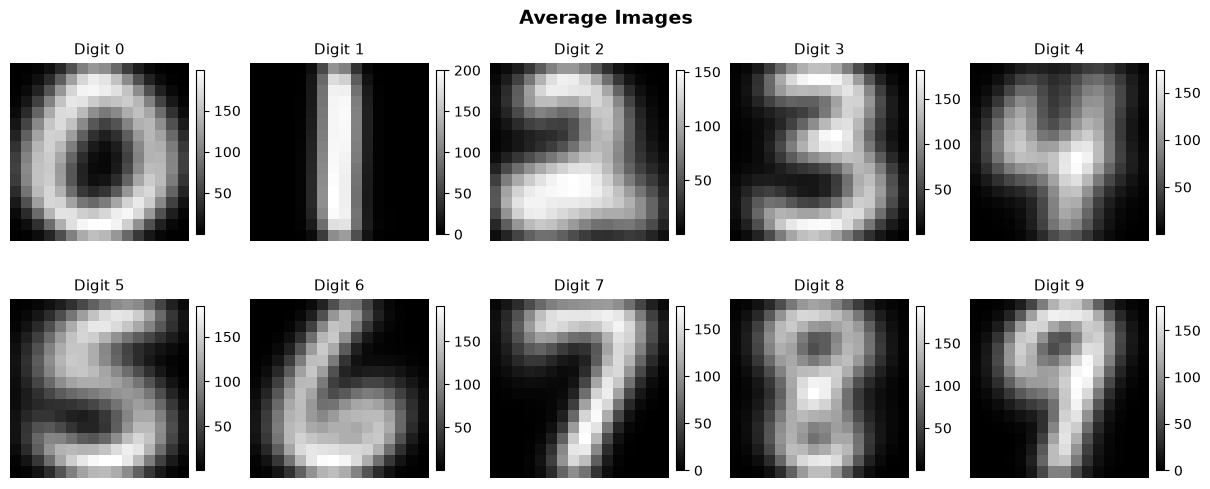

In [15]:
average_images: Dict[int, np.ndarray] = {}

for label in range(NUM_LABELS):
    imgs = images_by_label[label]
    if not imgs:
        raise RuntimeError(f"No images found for label {label}.")

    # Stack nested lists into (N, 16, 16) array and take mean along axis 0
    stack = np.array(imgs, dtype=np.float64)
    mean = stack.mean(axis=0)

    average_images[label] = mean

print(
    f"  A dictionary of NumPy arrays of shape (16, 16) containing pixel averages is computed."
)

# Normalizes and display individual average representations
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(12, 5), constrained_layout=True)
fig.suptitle(
    "Average Images",
    fontsize=14,
    fontweight="bold",
)

for label, ax in zip(range(NUM_LABELS), axes.flat):
    arr = average_images[label]
    # Normalize to standard uint8 intensity range [0, 255]
    arr_min, arr_max = arr.min(), arr.max()
    if arr_max > arr_min:
        normalised = ((arr - arr_min) / (arr_max - arr_min) * 255).astype(np.uint8)
    else:
        # Prevent division by zero if all pixels are identical
        normalised = np.zeros_like(arr, dtype=np.uint8)

    img = Image.fromarray(normalised, mode="L")

    if arr is not None:
        im = ax.imshow(arr, cmap="gray", interpolation="nearest")
        ax.set_title(f"Digit {label}", fontsize=11)
        # Attach color bar for precise scaling reference
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.axis("off")

plt.show()

#### 4. Pick user image via file dialog

Opens a Tkinter file dialog and returns the chosen image path.



[Input] Please select a photograph of your handwritten digit.


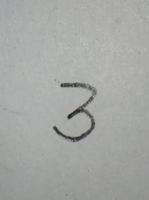

In [16]:
import sys
import os

from IPython.display import display
import tkinter as tk
from tkinter import filedialog, messagebox

print("\n[Input] Please select a photograph of your handwritten digit.")

# Hide the main Tk window; we only need the dialog widget
root = tk.Tk()
root.withdraw()
root.attributes("-topmost", True)  # Bring dialog to the front on Windows

file_types = [
    ("Image files", "*.png *.jpg *.jpeg *.bmp"),
    ("PNG", "*.png"),
    ("JPEG", "*.jpg *.jpeg"),
    ("BMP", "*.bmp"),
    ("All files", "*.*"),
]

test_image_path: str = filedialog.askopenfilename(
    title="Select a handwritten digit image",
    filetypes=file_types,
)
root.destroy()

if not test_image_path:
    print("No file selected. Exiting.")
    sys.exit(0)

# Validate extension
ext = os.path.splitext(test_image_path)[1].lower()
if ext not in SUPPORTED_EXTENSIONS:
    messagebox.showerror(
        "Unsupported Format",
        f"File extension '{ext}' is not supported.\n"
        f"Please choose one of: {', '.join(SUPPORTED_EXTENSIONS)}",
    )
    sys.exit(1)

# Display the selected image
img = Image.open(test_image_path)
w, h = img.size
display(img.resize((int(200 * w / h), 200), Image.Resampling.LANCZOS))

#### 5. Preprocess user image

Runs the full image_to_usps preprocessing pipeline and returns every stage.



[Preprocessing] Loading image...
  Original size: 470 x 627 px
[Preprocessing] Converting to grayscale...
[Preprocessing] Detecting digit (connected-component analysis)...
  Foreground Components Kept : 2
  Noise Components Removed   : 0
  Bounding Box               : (167, 259, 304, 446)


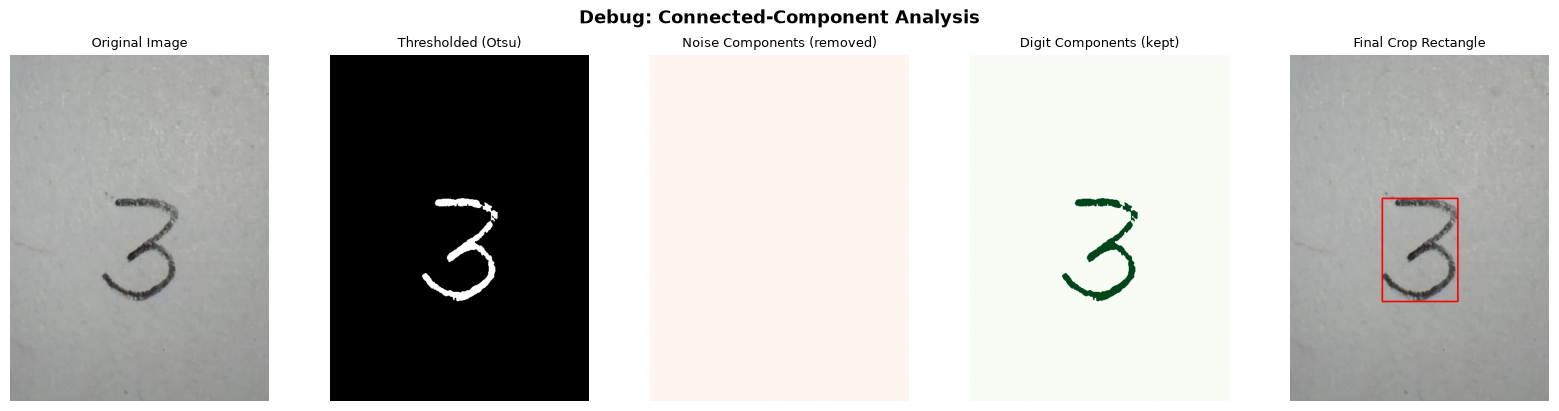

In [17]:
import cv2
import matplotlib.pyplot as plt


# Loads an image from disk and returns both a colour and a grayscale version.
print("\n[Preprocessing] Loading image...")
if not os.path.isfile(test_image_path):
    raise FileNotFoundError(f"Image file not found: {test_image_path}")
# cv2.IMREAD_COLOR loads RGB channels even for grayscale source images
colour_bgr = cv2.imread(test_image_path, cv2.IMREAD_COLOR)

if colour_bgr is None:
    raise ValueError(f"OpenCV could not decode the image: {test_image_path}")
gray: np.ndarray = cv2.cvtColor(colour_bgr, cv2.COLOR_BGR2GRAY)
print(f"  Original size: {colour_bgr.shape[1]} x {colour_bgr.shape[0]} px")


print("[Preprocessing] Converting to grayscale...")
# gray is already computed inside load_image


# Finds the smallest bounding box enclosing ALL significant digit components.
print("[Preprocessing] Detecting digit (connected-component analysis)...")
h, w = gray.shape
image_area: int = h * w
min_area: int = max(1, int(image_area * NOISE_AREA_THRESHOLD))

# Gaussian blur smooths JPEG compression artefacts and sensor noise
# before thresholding so small noise blobs merge or disappear.
blurred: np.ndarray = cv2.GaussianBlur(gray, (5, 5), 0)

# Otsu threshold.  THRESH_BINARY_INV makes the dark digit white (255)
# and the light background black (0).
_, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)

# Connected-component analysis.
# Returns: num_labels, label_map, stats array, centroids.
# stats columns: LEFT, TOP, WIDTH, HEIGHT, AREA (index constants below).
num_labels, label_map, stats, _ = cv2.connectedComponentsWithStats(
    binary, connectivity=8
)

# Accumulate union bounding box across all kept components
union_left = w  # start at far right; will shrink inward
union_top = h
union_right = 0  # start at far left; will grow outward
union_bottom = 0

kept_mask: np.ndarray = np.zeros((h, w), dtype=np.uint8)
noise_mask: np.ndarray = np.zeros((h, w), dtype=np.uint8)
n_kept = 0
n_noise = 0

# Iterate labels; skip background (label 0).
for label in range(1, num_labels):
    area = int(stats[label, cv2.CC_STAT_AREA])
    comp_mask = (label_map == label).astype(np.uint8) * 255

    if area < min_area:
        # Component is clearly noise; record it for debug display but discard.
        noise_mask = cv2.bitwise_or(noise_mask, comp_mask)
        n_noise += 1
        continue

    # Significant component: expand the union bounding box.
    x0 = int(stats[label, cv2.CC_STAT_LEFT])
    y0 = int(stats[label, cv2.CC_STAT_TOP])
    x1 = x0 + int(stats[label, cv2.CC_STAT_WIDTH])
    y1 = y0 + int(stats[label, cv2.CC_STAT_HEIGHT])

    union_left = min(union_left, x0)
    union_top = min(union_top, y0)
    union_right = max(union_right, x1)
    union_bottom = max(union_bottom, y1)

    kept_mask = cv2.bitwise_or(kept_mask, comp_mask)
    n_kept += 1

if n_kept == 0:
    raise ValueError(
        "No digit pixels survived noise filtering. "
        "Check that the image contains a dark handwritten digit on a light background."
    )

# Tight bbox before padding (reported in diagnostics)
bbox: Tuple[int, int, int, int] = (union_left, union_top, union_right, union_bottom)

bw = union_right - union_left
bh = union_bottom - union_top

# Add a small safety margin around the tight bbox
margin_x = max(1, int(bw * PADDING_FRACTION))
margin_y = max(1, int(bh * PADDING_FRACTION))

left_pad = max(0, union_left - margin_x)
top_pad = max(0, union_top - margin_y)
right_pad = min(w, union_right + margin_x)
bottom_pad = min(h, union_bottom + margin_y)

cropped = gray[top_pad:bottom_pad, left_pad:right_pad]

left, top, right, bottom = bbox

print(f"  Foreground Components Kept : {n_kept}")
print(f"  Noise Components Removed   : {n_noise}")
print(f"  Bounding Box               : ({left}, {top}, {right}, {bottom})")


# Displays a debug figure showing connected-component analysis results.
colour_rgb = cv2.cvtColor(colour_bgr, cv2.COLOR_BGR2RGB)

# Draw the crop rectangle on a copy of the colour image
bbox_img = colour_rgb.copy()
left, top, right, bottom = bbox
cv2.rectangle(bbox_img, (left, top), (right, bottom), color=(255, 0, 0), thickness=2)

fig, axes = plt.subplots(1, 5, figsize=(16, 4), constrained_layout=True)
fig.suptitle(
    "Debug: Connected-Component Analysis",
    fontsize=13,
    fontweight="bold",
)

panels = [
    (colour_rgb, "Original Image", None),
    (binary, "Thresholded (Otsu)", "gray"),
    (noise_mask, "Noise Components (removed)", "Reds"),
    (kept_mask, "Digit Components (kept)", "Greens"),
    (bbox_img, "Final Crop Rectangle", None),
]

for ax, (img, title, cmap) in zip(axes, panels):
    if img.ndim == 3 or cmap is None:
        ax.imshow(img)
    else:
        ax.imshow(img, cmap=cmap, vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.show()

[Preprocessing] Centering and padding digit...
[Preprocessing] Resizing to 16x16...
[Preprocessing] Applying USPS color convention (invert if needed)...
  Light background detected -> inverted (dark digit => white on black).


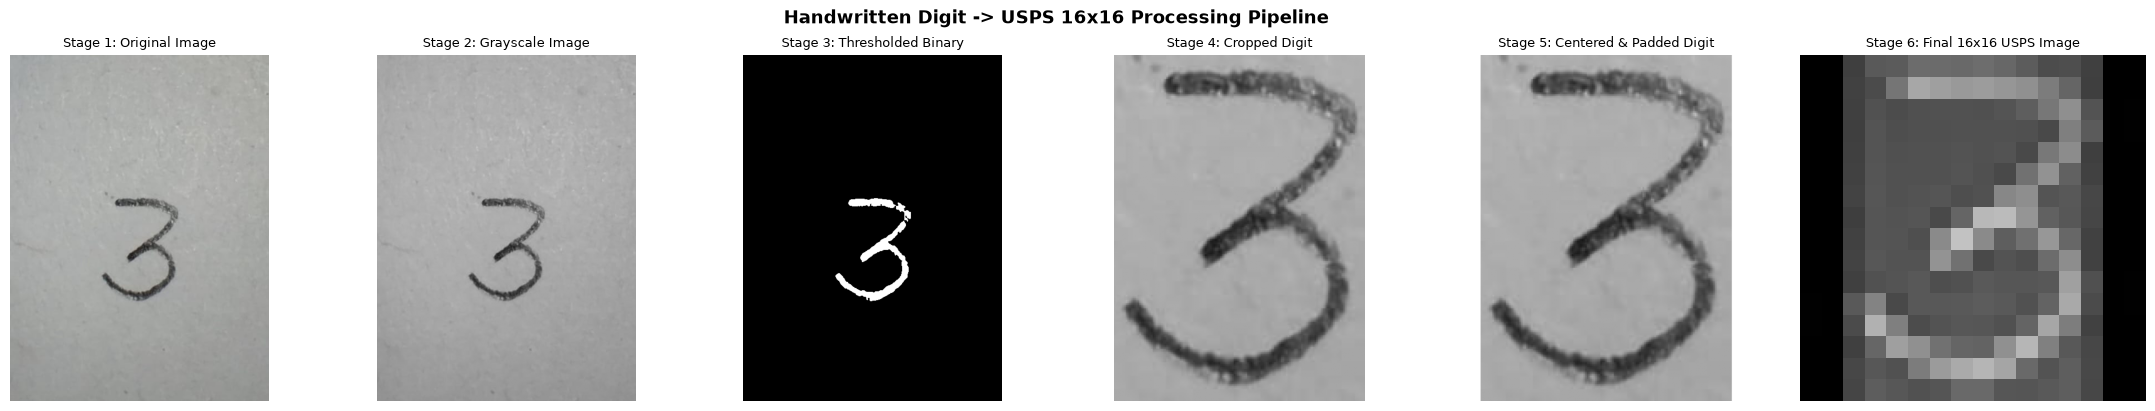

In [18]:
# Expands the shorter dimension of a cropped image to form a square.
print("[Preprocessing] Centering and padding digit...")
h, w = cropped.shape
size = max(h, w)

# Create a white canvas (255) so unfilled regions look like paper background
padded: np.ndarray = np.full((size, size), 255, dtype=np.uint8)

# Compute offsets to centre the digit within the square
top_offset = (size - h) // 2
left_offset = (size - w) // 2

padded[top_offset : top_offset + h, left_offset : left_offset + w] = cropped


# Resizes the square digit image to (size x size) using Lanczos resampling.
print("[Preprocessing] Resizing to 16x16...")
size: int = TARGET_SIZE
pil_img = Image.fromarray(padded)
pil_resized = pil_img.resize((size, size), resample=Image.Resampling.LANCZOS)
resized = np.array(pil_resized, dtype=np.uint8)


# Inverts pixel values if the image has a light background.
print("[Preprocessing] Applying USPS color convention (invert if needed)...")
mean_value: float = float(resized.mean())
if mean_value > 127:
    # Light background detected -> invert
    final = (255 - resized).astype(np.uint8)
    print("  Light background detected -> inverted (dark digit => white on black).")
else:
    final = resized.copy()
    print("  Dark background detected -> no inversion applied.")


# Asserts that the processed image meets all dimension and value constraints.
# Validate all constraints before proceeding
expected_size: int = TARGET_SIZE
assert final.ndim == 2, f"Expected 2D array, got {final.ndim}D"
assert final.shape == (
    expected_size,
    expected_size,
), f"Expected ({expected_size}, {expected_size}), got {final.shape}"
assert final.dtype == np.uint8, f"Expected uint8, got {final.dtype}"
assert final.min() >= 0, f"Pixel value below 0: {final.min()}"
assert final.max() <= 255, f"Pixel value above 255: {final.max()}"


# Displays each processing stage in a Matplotlib subplot figure.
# Convert BGR to RGB for correct Matplotlib colour rendering
colour_rgb = cv2.cvtColor(colour_bgr, cv2.COLOR_BGR2RGB)

stages = [
    (colour_rgb, "Stage 1: Original Image", None),
    (gray, "Stage 2: Grayscale Image", "gray"),
    (binary, "Stage 3: Thresholded Binary", "gray"),
    (cropped, "Stage 4: Cropped Digit", "gray"),
    (padded, "Stage 5: Centered & Padded Digit", "gray"),
    (final, "Stage 6: Final 16x16 USPS Image", "gray"),
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=6,
    figsize=(22, 4),
    constrained_layout=True,
)
fig.suptitle(
    "Handwritten Digit -> USPS 16x16 Processing Pipeline",
    fontsize=13,
    fontweight="bold",
)

for ax, (img, title, cmap) in zip(axes, stages):
    if img.ndim == 3 or cmap is None:
        ax.imshow(img)
    else:
        ax.imshow(img, cmap=cmap, vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.show()

In [19]:
# Converts a NumPy array to a nested Python list of integer pixel values.
pixel_array = final.astype(int).tolist()


# Asserts that the nested list has the correct dimensions.
expected_size: int = TARGET_SIZE
assert (
    len(pixel_array) == expected_size
), f"Array has {len(pixel_array)} rows; expected {expected_size}"
for i, row in enumerate(pixel_array):
    assert (
        len(row) == expected_size
    ), f"Row {i} has {len(row)} columns; expected {expected_size}"


# Prints the 16x16 pixel array and image statistics to the terminal.
size: int = TARGET_SIZE
flat = [v for row in pixel_array for v in row]
black_count = sum(1 for v in flat if v == 0)
white_count = sum(1 for v in flat if v == 255)

print(f"\n{'=' * 56}")
print(f"Image Shape: {size} x {size}")
print()
for row in pixel_array:
    formatted = ", ".join(f"{v:>3}" for v in row)
    print(f"[{formatted}]")
print(f"\nWidth              : {size}")
print(f"Height             : {size}")
print(f"Minimum Pixel Value: {min(flat)}")
print(f"Maximum Pixel Value: {max(flat)}")
print(f"Average Pixel Value: {sum(flat) / len(flat):.2f}")
print(f"\nBlack Pixel Count  : {black_count}")
print(f"White Pixel Count  : {white_count}")
print(f"\nColor Convention:")
print(f"  Background = Black (0)")
print(f"  Digit      = White (255)")
print(f"{'=' * 56}\n")


Image Shape: 16 x 16

[  0,   0,  63,  90,  91, 108, 107, 105, 109, 103,  92,  76,  78,  64,   0,   0]
[  0,   0,  65,  75, 117, 167, 159, 153, 156, 150, 144, 124, 101,  63,   0,   0]
[  0,   0,  64,  81,  76,  80,  81,  81,  80,  84,  94, 119, 143,  83,   0,   1]
[  0,   0,  63,  84,  78,  80,  80,  81,  81,  81,  80,  73, 127,  91,   0,   1]
[  0,   0,  64,  84,  80,  82,  82,  83,  82,  83,  73, 120, 140,  63,   0,   0]
[  0,   0,  65,  85,  82,  81,  82,  84,  80,  74, 113, 146,  98,  65,   0,   0]
[  0,   0,  67,  86,  81,  83,  85,  78,  82, 135, 142,  84,  88,  71,   0,   0]
[  0,   0,  62,  85,  83,  85,  73, 101, 184, 187, 149,  98,  87,  70,   0,   0]
[  0,   0,  65,  85,  84,  79, 138, 194, 138,  94, 112, 151, 103,  65,   0,   0]
[  0,   0,  67,  87,  83,  83, 148, 113,  74,  83,  78, 108, 141,  66,   0,   0]
[  0,   0,  64,  82,  84,  88,  78,  82,  90,  86,  86,  88, 160,  80,   0,   1]
[  1,   0,  90, 131,  74,  88,  88,  90,  92,  89,  81,  99, 169,  75,   0,   1]
[  1,

#### 6. Classify by Euclidean distance

Computes Euclidean distance from the user image to every average template.


In [20]:
print("[Classification] Computing Euclidean distances...")

# Validate user image dimensions
if final.shape != (TARGET_SIZE, TARGET_SIZE):
    raise ValueError(
        f"User image shape {final.shape} is not ({TARGET_SIZE}, {TARGET_SIZE})."
    )

# Flatten user image to a 256-element float vector once
user_vec: np.ndarray = final.flatten().astype(np.float64)  # shape: (256,)

distances: Dict[int, float] = {}
for label, avg_array in average_images.items():
    # Validate each template
    if np.array(avg_array).shape != (TARGET_SIZE, TARGET_SIZE):
        raise ValueError(
            f"Template for label {label} has shape {np.array(avg_array).shape}; "
            f"expected ({TARGET_SIZE}, {TARGET_SIZE})."
        )

    # Flatten template and compute L2 norm of the difference vector
    template_vec: np.ndarray = np.array(avg_array).flatten()  # shape: (256,)
    dist: float = float(np.linalg.norm(user_vec - template_vec))
    distances[label] = dist

# Prints the Euclidean distance from the user digit to every template.
print(f"\n{'=' * 42}")
print("  Euclidean Distances to Each Template")
print(f"{'=' * 42}")
for label in range(NUM_LABELS):
    print(f"  Distance to {label}: {distances[label]:.2f}")
print(f"{'=' * 42}\n")

[Classification] Computing Euclidean distances...

  Euclidean Distances to Each Template
  Distance to 0: 901.44
  Distance to 1: 1174.59
  Distance to 2: 698.81
  Distance to 3: 596.79
  Distance to 4: 805.36
  Distance to 5: 625.86
  Distance to 6: 825.29
  Distance to 7: 924.18
  Distance to 8: 634.03
  Distance to 9: 847.21



#### 7. Visualisation


In [21]:
# Prints all labels sorted by increasing (best to worst) distance.
sorted_labels: List[int] = sorted(distances, key=lambda k: distances[k])
print(f"{'=' * 42}")
print("Similarity Ranking (closest first):")
print(f"{'=' * 42}")
for rank, label in enumerate(sorted_labels, start=1):
    print(f"  {rank}. Digit {label}  ->  {distances[label]:.2f}")
print(f"{'=' * 42}")

predicted_digit: int = min(distances, key=lambda k: distances[k])
min_distance: float = distances[predicted_digit]

# Prints the final classification result block.
print(f"\n{'=' * 42}")
print("  Digit Classification Complete")
print(f"{'=' * 42}")
print(f"  Predicted Digit            : {predicted_digit}")
print(f"  Minimum Euclidean Distance : {min_distance:.2f}")
print(f"  Closest Average Template   : Label {predicted_digit}")
print(f"{'=' * 42}\n")

Similarity Ranking (closest first):
  1. Digit 3  ->  596.79
  2. Digit 5  ->  625.86
  3. Digit 8  ->  634.03
  4. Digit 2  ->  698.81
  5. Digit 4  ->  805.36
  6. Digit 6  ->  825.29
  7. Digit 9  ->  847.21
  8. Digit 0  ->  901.44
  9. Digit 7  ->  924.18
  10. Digit 1  ->  1174.59

  Digit Classification Complete
  Predicted Digit            : 3
  Minimum Euclidean Distance : 596.79
  Closest Average Template   : Label 3



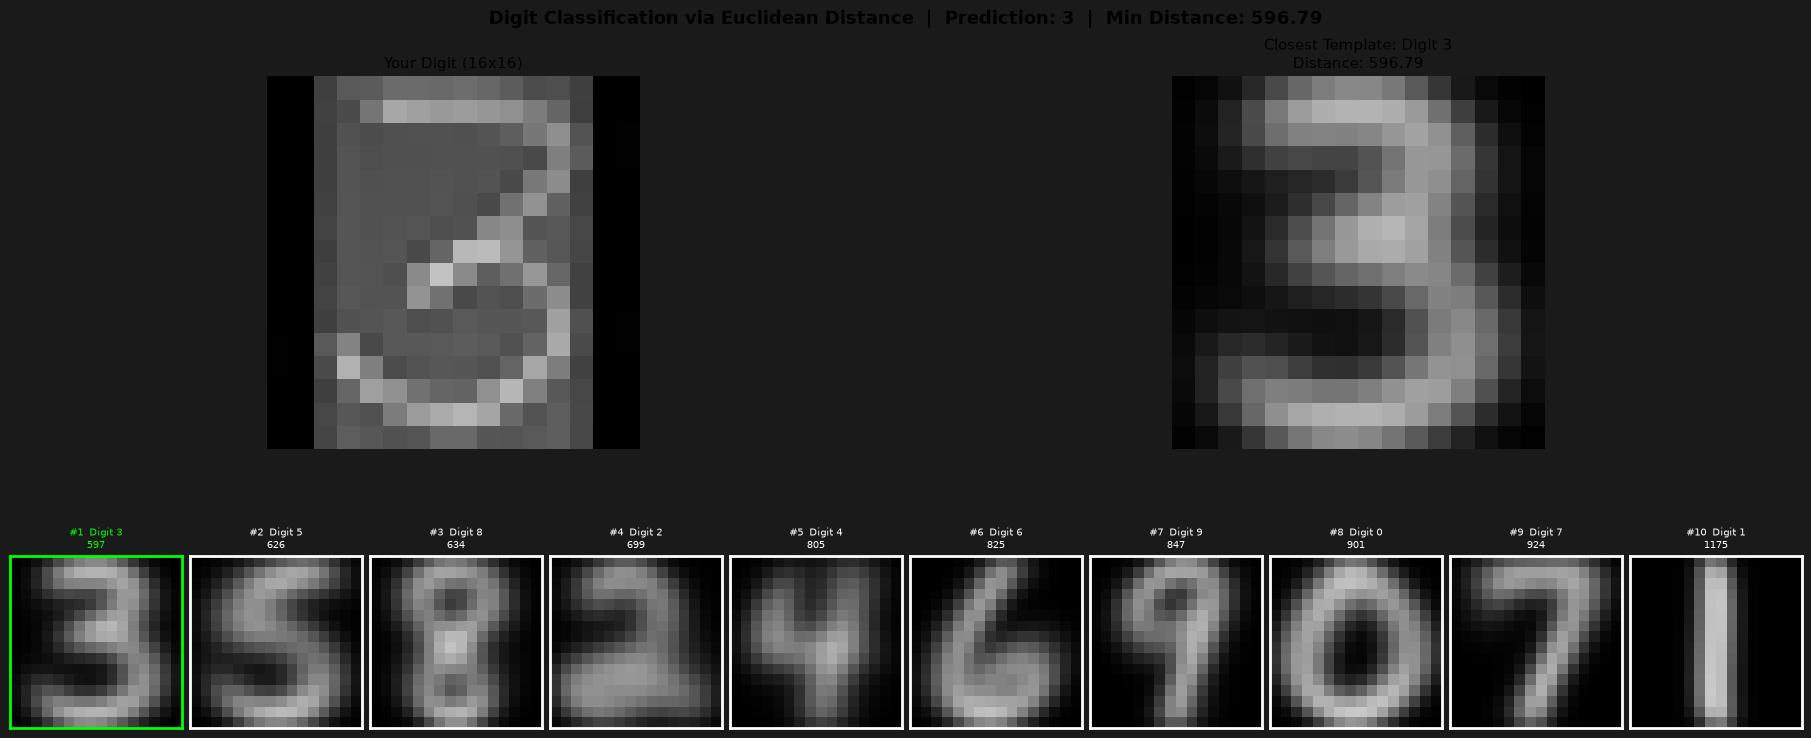

In [22]:
# Displays a Matplotlib figure comparing the user's digit to all templates.
min_distance = distances[predicted_digit]
sorted_labels = sorted(distances, key=lambda k: distances[k])

fig = plt.figure(figsize=(18, 8), constrained_layout=True)
fig.suptitle(
    f"Digit Classification via Euclidean Distance  |  "
    f"Prediction: {predicted_digit}  |  Min Distance: {min_distance:.2f}",
    fontsize=13,
    fontweight="bold",
)

# ---- Top row: user image vs. closest template ----------------------------
gs_top = fig.add_gridspec(2, 2, height_ratios=[1.4, 1], hspace=0.45)

ax_user = fig.add_subplot(gs_top[0, 0])
ax_user.imshow(final, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
ax_user.set_title("Your Digit (16x16)", fontsize=11)
ax_user.axis("off")

ax_match = fig.add_subplot(gs_top[0, 1])
ax_match.imshow(
    average_images[predicted_digit],
    cmap="gray",
    vmin=0,
    vmax=255,
    interpolation="nearest",
)
ax_match.set_title(
    f"Closest Template: Digit {predicted_digit}\nDistance: {min_distance:.2f}",
    fontsize=11,
)
ax_match.axis("off")

# ---- Bottom row: all 10 templates ranked ---------------------------------
gs_bottom = fig.add_gridspec(2, NUM_LABELS, height_ratios=[1.4, 1])

for rank, label in enumerate(sorted_labels):
    ax = fig.add_subplot(gs_bottom[1, rank])
    ax.imshow(
        average_images[label],
        cmap="gray",
        vmin=0,
        vmax=255,
        interpolation="nearest",
    )
    # Highlight predicted digit with a coloured border
    border_color = "lime" if label == predicted_digit else "white"
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(2)
    ax.set_title(
        f"#{rank + 1}  Digit {label}\n{distances[label]:.0f}",
        fontsize=7.5,
        color="lime" if label == predicted_digit else "white",
    )
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax.set_facecolor("#1a1a1a")

fig.patch.set_facecolor("#1a1a1a")
plt.show()